---
title: "Latent ODE on spirals"
short_title: "03 · Latent ODE"
subtitle: "Gaussianization moves into a latent space: encode an irregular trajectory to a code z0, push the prior to N(0,I), and let a neural ODE carry the dynamics — a stochastic, amortized Gaussianizer and the bridge to time series"
description: >
  The bijective continuous flows of 6.0-6.2 map data <-> N(0,I) one point at a time.
  A latent ODE Gaussianizes differently: a neural-ODE encoder maps a whole
  irregularly-sampled trajectory to a latent code z0, a VAE prior pulls the code
  toward N(0,I), and a second neural ODE evolves z(t) for reconstruction and
  extrapolation. This notebook builds the Rubanova-Chen-Duvenaud latent ODE on toy
  spirals with gauss_flows' DiffeqMLP + diffrax, frames it as a stochastic
  (SurVAE-style) Gaussianizer of trajectories, and closes Part 6 by pointing at the
  time-series parts.
---

(sec-nb-ct-03)=
# 03 — Latent ODE on spirals

Notebooks [00](00_ffjord_2d.ipynb)-[02](02_matrix_exponential_flow.ipynb)
Gaussianized with **bijections**: a deterministic, invertible map carries each data
point to $\mathcal{N}(0,I)$ and back, with an exact (or estimated) log-det. That
contract breaks the moment the data is a *variable-length, irregularly-sampled
trajectory* — there is no fixed-dimensional $x$ to invert. The **latent ODE**
(Rubanova, Chen & Duvenaud {cite}`rubanova2019latentode`, {cite}`kidger2021ndes`)
Gaussianizes such data a different way:

1. **Encode** the whole trajectory $\{(t_i, x_i)\}$ to a single latent code with a
   neural-ODE encoder, producing $q(z_0\mid x_{1:N}) = \mathcal{N}(\mu, \sigma^2)$.
2. **Gaussianize the code** by pulling $q(z_0)$ toward the prior $\mathcal{N}(0,I)$
   through the ELBO's KL term — *targeting* a standard-normal latent (how close it
   actually gets is itself instructive; see §6).
3. **Evolve** $z(t)$ with a second neural ODE $\dot z = f_\theta(z,t)$ and **decode**
   $z(t_i)\mapsto \hat x_i$.

This is a **stochastic** Gaussianizer, not a bijection — the SurVAE-style cousin
(Part 8) of the flows above. It trades exact invertibility for two things the
bijections cannot do: ingest irregular sequences of any length, and change
dimension ($\mathbb{R}^{N\times 2}\to\mathbb{R}^{d_z}$). The ODE prior also makes
**extrapolation** natural — integrate $z(t)$ past the last observation. It is the
bridge from Part 6 to the time-series Gaussianization of Part 11.

**What you will see**

- Toy spirals, densely defined but **irregularly observed** (the realistic setting).
- The encode → latent-ODE → decode VAE, trained by ELBO with `gf.DiffeqMLP` fields.
- **Reconstruction** of held-out spirals from a handful of irregular points.
- **Extrapolation** beyond the observed window by integrating the latent ODE forward.
- The **latent Gaussianization** — and the topological obstruction (a circular phase
  cannot be pushed into a Euclidean Gaussian) that keeps it only approximate.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import diffrax
import equinox as eqx
import interpax
import jax
import jax.nn as jnn
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from scipy import stats

from gauss_flows import DiffeqMLP, pack_time_control
from _style import DATA_COLOR, GAUSS_KW, LATENT_COLOR, SCATTER_KW, style_ax

jax.config.update("jax_enable_x64", True)

## 1. Irregularly-sampled spiral dataset

Following Rubanova et al. §4.1: 2-D spirals with a random phase and a random
direction (clockwise / counter-clockwise), defined densely on a common grid but then
**irregularly subsampled** with additive noise — the situation real sensors produce.
A held-out split backs the reconstruction and extrapolation figures.

250 spirals (200 train / 50 eval), 30 irregular obs each on t in [0, 5.0]


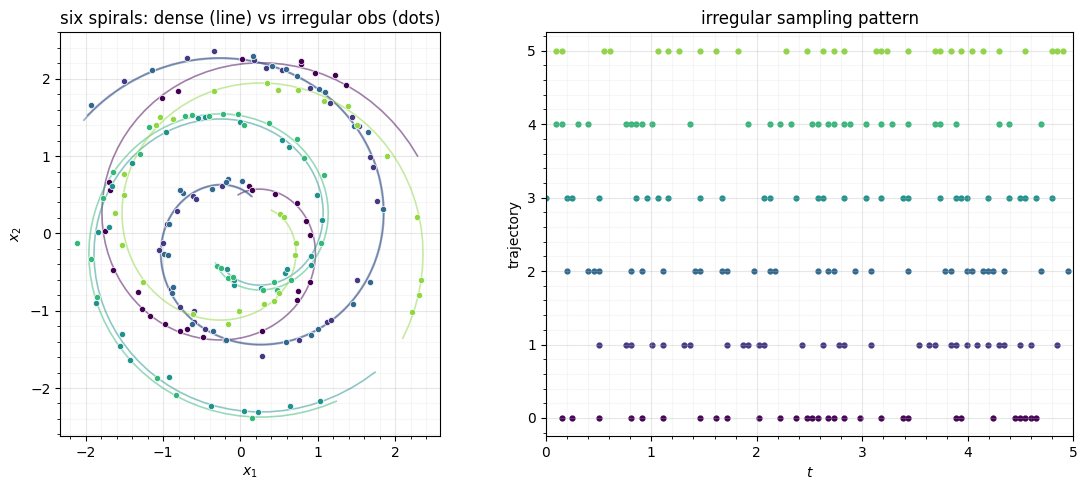

In [2]:
N_TRAJ, N_EVAL = 250, 50
T_MAX, N_DENSE, N_OBS, NOISE_STD = 5.0, 100, 30, 0.05


def _spiral(key, t):
    rot_key, dir_key = jr.split(key)
    theta = jr.uniform(rot_key, minval=0.0, maxval=2 * jnp.pi)
    direction = jr.choice(dir_key, jnp.array([-1.0, 1.0]))
    r = 0.4 * t + 0.5
    angle = direction * (1.5 * t) + theta
    return jnp.stack([r * jnp.cos(angle), r * jnp.sin(angle)], axis=-1)


def make_dataset(key, n_traj):
    spiral_key, sample_key, noise_key = jr.split(key, 3)
    t_dense = jnp.linspace(0.0, T_MAX, N_DENSE)

    def per_traj(sk, mk):
        x_clean = _spiral(sk, t_dense)
        idx = jnp.sort(jr.choice(mk, N_DENSE, shape=(N_OBS,), replace=False))
        return x_clean, t_dense[idx], x_clean[idx]

    x_clean, t_obs, x_obs_clean = jax.vmap(per_traj)(
        jr.split(spiral_key, n_traj), jr.split(sample_key, n_traj)
    )
    x_obs = x_obs_clean + NOISE_STD * jr.normal(noise_key, x_obs_clean.shape)
    return t_dense, x_clean, t_obs, x_obs


t_dense, x_clean, t_obs, x_obs = make_dataset(jr.key(0), N_TRAJ)
n_train = N_TRAJ - N_EVAL
t_obs_tr, t_obs_ev = t_obs[:n_train], t_obs[n_train:]
x_obs_tr, x_obs_ev = x_obs[:n_train], x_obs[n_train:]
x_clean_ev = x_clean[n_train:]
print(f"{N_TRAJ} spirals ({n_train} train / {N_EVAL} eval), "
      f"{N_OBS} irregular obs each on t in [0, {T_MAX}]")

fig, (ax_xy, ax_t) = plt.subplots(1, 2, figsize=(11.5, 5))
for k in range(6):
    c = plt.cm.viridis(k / 6)
    ax_xy.plot(np.asarray(x_clean[k, :, 0]), np.asarray(x_clean[k, :, 1]), color=c, alpha=0.5, lw=1.2)
    ax_xy.scatter(np.asarray(x_obs[k, :, 0]), np.asarray(x_obs[k, :, 1]), s=20, color=c,
                  edgecolor="white", linewidth=0.5, zorder=3)
    ax_t.scatter(np.asarray(t_obs[k]), np.full(N_OBS, k), s=12, color=c)
ax_xy.set(title="six spirals: dense (line) vs irregular obs (dots)", xlabel="$x_1$", ylabel="$x_2$")
ax_xy.set_aspect("equal"); style_ax(ax_xy)
ax_t.set(title="irregular sampling pattern", xlabel="$t$", ylabel="trajectory", xlim=(0, T_MAX))
style_ax(ax_t)
fig.tight_layout()

## 2. The model: encode → latent ODE → decode

Three small modules, both vector fields being `gf.DiffeqMLP`. The **encoder** runs a
forward neural ODE on the linearly-interpolated observation path $\hat X(t)$ — the
observations enter as the *control* of the time-control condition, so the same
`DiffeqMLP` plumbing that FFJORD used carries over — and maps the final hidden state
to $(\mu, \log\sigma^2)$ of $q(z_0)$. The **dynamics** field evolves $z(t)$; the
**decoder** is an MLP $z(t_i)\mapsto\hat x_i$ with fixed observation noise.

In [3]:
OBS_DIM, LATENT_DIM, ENC_HIDDEN, DEC_HIDDEN, SIGMA_OBS = 2, 4, 25, 20, 0.20


def _interp(t_query, t_traj, x_traj):
    return interpax.interp1d(jnp.atleast_1d(t_query), t_traj, x_traj, method="linear", extrap=True)[0]


def _solve(vf, y0, t0, t1, args=None, saveat=None):
    return diffrax.diffeqsolve(
        diffrax.ODETerm(vf), diffrax.Tsit5(), t0=t0, t1=t1, dt0=0.05, y0=y0, args=args,
        saveat=saveat or diffrax.SaveAt(t1=True),
        stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-4),
        adjoint=diffrax.RecursiveCheckpointAdjoint(), max_steps=4096,
    )


class LatentODE(eqx.Module):
    encoder_vf: DiffeqMLP
    enc_head: eqx.nn.Linear
    dynamics_vf: DiffeqMLP
    decoder: eqx.nn.MLP

    def __init__(self, key):
        ke, kh, kd, kc = jr.split(key, 4)
        self.encoder_vf = DiffeqMLP(ke, in_dim=ENC_HIDDEN, control_dim=OBS_DIM, hidden=(40, 40), activation=jnn.tanh)
        self.enc_head = eqx.nn.Linear(ENC_HIDDEN, 2 * LATENT_DIM, key=kh)
        self.dynamics_vf = DiffeqMLP(kd, in_dim=LATENT_DIM, control_dim=0, hidden=(40, 40), activation=jnn.tanh)
        self.decoder = eqx.nn.MLP(LATENT_DIM, OBS_DIM, DEC_HIDDEN, 2, activation=jnn.tanh, key=kc)

    def encode(self, t_traj, x_traj):
        def vf(t, h, args):
            return self.encoder_vf(t, h, pack_time_control(t, _interp(t, args[0], args[1])))

        h_final = _solve(vf, jnp.zeros(ENC_HIDDEN), t_traj[0], t_traj[-1], args=(t_traj, x_traj)).ys[-1]
        mu, log_var = jnp.split(self.enc_head(h_final), 2)
        return mu, jnp.clip(log_var, -8.0, 4.0)

    def decode(self, z0, times):
        z_traj = _solve(lambda t, z, a: self.dynamics_vf(t, z, None), z0, times[0], times[-1],
                        saveat=diffrax.SaveAt(ts=times)).ys
        return jax.vmap(self.decoder)(z_traj)

    def elbo(self, key, t_traj, x_traj):
        mu, log_var = self.encode(t_traj, x_traj)
        z0 = mu + jnp.exp(0.5 * log_var) * jr.normal(key, mu.shape)
        x_hat = self.decode(z0, t_traj)
        recon = jnp.sum(-0.5 * ((x_traj - x_hat) / SIGMA_OBS) ** 2 - jnp.log(SIGMA_OBS) - 0.5 * jnp.log(2 * jnp.pi))
        kl = 0.5 * jnp.sum(jnp.exp(log_var) + mu**2 - 1.0 - log_var)
        return recon - kl, recon, kl


model_key, train_key, eval_key = jr.split(jr.key(0), 3)
model = LatentODE(model_key)
n_params = sum(int(np.prod(p.shape)) for p in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)))
print(f"latent dim {LATENT_DIM}, encoder hidden {ENC_HIDDEN}, obs noise {SIGMA_OBS}")
print(f"trainable parameters: {n_params}")

latent dim 4, encoder hidden 25, obs noise 0.2
trainable parameters: 6679


## 3. Train by the ELBO

Each step encodes every trajectory with one forward ODE solve, samples $z_0$ by the
reparametrisation trick, decodes with a second ODE solve at the observed times, and
adds the Gaussian log-likelihood to the closed-form KL. Two ODE solves per
trajectory make this the heaviest cell in Part 6; a cosine learning-rate decay lets
it settle inside a short budget.

epoch    1  -ELBO    964.21  -recon    963.58  KL   0.62


epoch   40  -ELBO    519.39  -recon    498.69  KL  20.70


epoch   80  -ELBO    471.89  -recon    457.85  KL  14.04


epoch  120  -ELBO    460.54  -recon    447.08  KL  13.47


epoch  160  -ELBO    399.27  -recon    385.68  KL  13.59


epoch  200  -ELBO     63.93  -recon     48.07  KL  15.86


epoch  240  -ELBO     44.38  -recon     28.63  KL  15.76


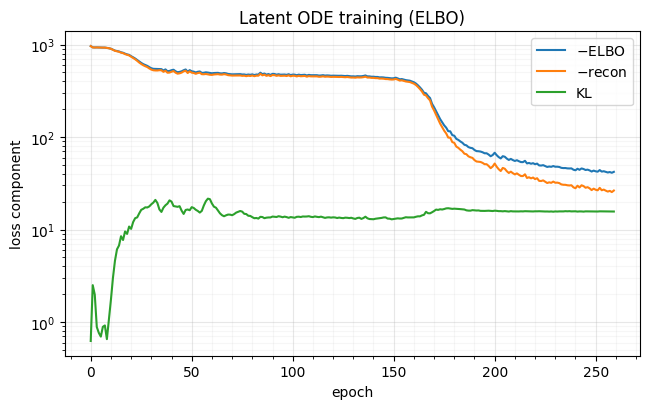

In [4]:
N_EPOCHS, BATCH = 260, 50
n_batches = n_train // BATCH
lr = optax.cosine_decay_schedule(3e-3, decay_steps=N_EPOCHS * n_batches, alpha=0.02)
optimizer = optax.chain(optax.clip_by_global_norm(5.0), optax.adam(lr))
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


@eqx.filter_jit
def loss_fn(model, key, t_b, x_b):
    keys = jr.split(key, t_b.shape[0])
    e, r, k = jax.vmap(model.elbo)(keys, t_b, x_b)
    return -jnp.mean(e), (jnp.mean(r), jnp.mean(k))


@eqx.filter_jit
def step(model, opt_state, key, t_b, x_b):
    (loss, (recon, kl)), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(model, key, t_b, x_b)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    return eqx.apply_updates(model, updates), opt_state, loss, recon, kl


losses, recons, kls = [], [], []
for epoch in range(N_EPOCHS):
    train_key, perm_key, batch_key = jr.split(train_key, 3)
    perm = jr.permutation(perm_key, n_train)
    t_sh, x_sh = t_obs_tr[perm], x_obs_tr[perm]
    el, er, ek = 0.0, 0.0, 0.0
    for b in range(n_batches):
        sl = slice(b * BATCH, (b + 1) * BATCH)
        batch_key, sub = jr.split(batch_key)
        model, opt_state, loss, recon, kl = step(model, opt_state, sub, t_sh[sl], x_sh[sl])
        el += float(loss); er += float(recon); ek += float(kl)
    losses.append(el / n_batches); recons.append(er / n_batches); kls.append(ek / n_batches)
    if epoch == 0 or (epoch + 1) % 40 == 0:
        print(f"epoch {epoch + 1:>4d}  -ELBO {losses[-1]:>9.2f}  -recon {-recons[-1]:>9.2f}  KL {kls[-1]:>6.2f}")

fig, ax = plt.subplots(figsize=(6.6, 4.2))
ep = np.arange(len(losses))
ax.plot(ep, losses, color=DATA_COLOR, label="$-$ELBO")
ax.plot(ep, [-r for r in recons], color=LATENT_COLOR, label="$-$recon")
ax.plot(ep, kls, color="tab:green", label="KL")
ax.set(xlabel="epoch", ylabel="loss component", title="Latent ODE training (ELBO)", yscale="log")
ax.legend()
style_ax(ax)
fig.tight_layout()

## 4. Reconstruction from irregular observations

For each held-out spiral we encode its handful of irregular, noisy points, then
decode on the **dense** grid. The latent ODE produces a smooth curve that threads the
observations — interpolation in continuous time, learned from the trajectory family.

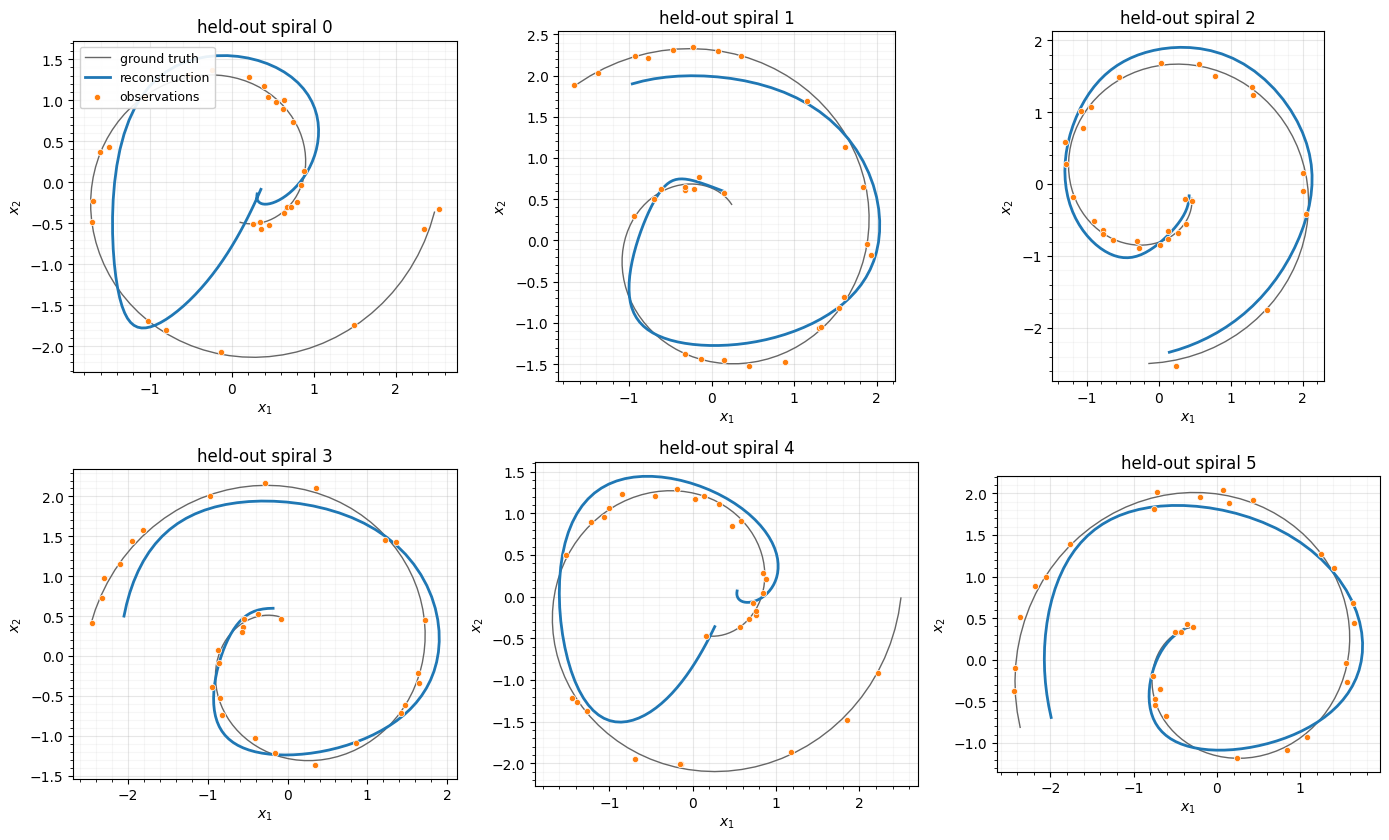

In [5]:
@eqx.filter_jit
def reconstruct(model, key, t_traj, x_traj, t_target):
    mu, log_var = model.encode(t_traj, x_traj)
    z0 = mu + jnp.exp(0.5 * log_var) * jr.normal(key, mu.shape)
    return model.decode(z0, t_target)


rec_keys = jr.split(eval_key, 6)
fig, axes = plt.subplots(2, 3, figsize=(14, 8.5))
for k, ax in enumerate(axes.flat):
    x_hat = reconstruct(model, rec_keys[k], t_obs_ev[k], x_obs_ev[k], t_dense)
    ax.plot(np.asarray(x_clean_ev[k, :, 0]), np.asarray(x_clean_ev[k, :, 1]), color="0.4", lw=1.0, label="ground truth")
    ax.plot(np.asarray(x_hat[:, 0]), np.asarray(x_hat[:, 1]), color=DATA_COLOR, lw=2.0, label="reconstruction")
    ax.scatter(np.asarray(x_obs_ev[k, :, 0]), np.asarray(x_obs_ev[k, :, 1]), s=20, color=LATENT_COLOR,
               edgecolor="white", linewidth=0.5, zorder=3, label="observations")
    ax.set(title=f"held-out spiral {k}", xlabel="$x_1$", ylabel="$x_2$")
    ax.set_aspect("equal"); style_ax(ax)
    if k == 0:
        ax.legend(loc="upper left", framealpha=0.9, fontsize=9)
fig.tight_layout()

## 5. Extrapolation past the observed window

Because the latent prior is an ODE, the model extrapolates for free: encode using
only the observations on $[0, T/2]$, then integrate $z(t)$ all the way to $T$. The
dashed arm is pure forward prediction — the model never saw those times for this
trajectory.

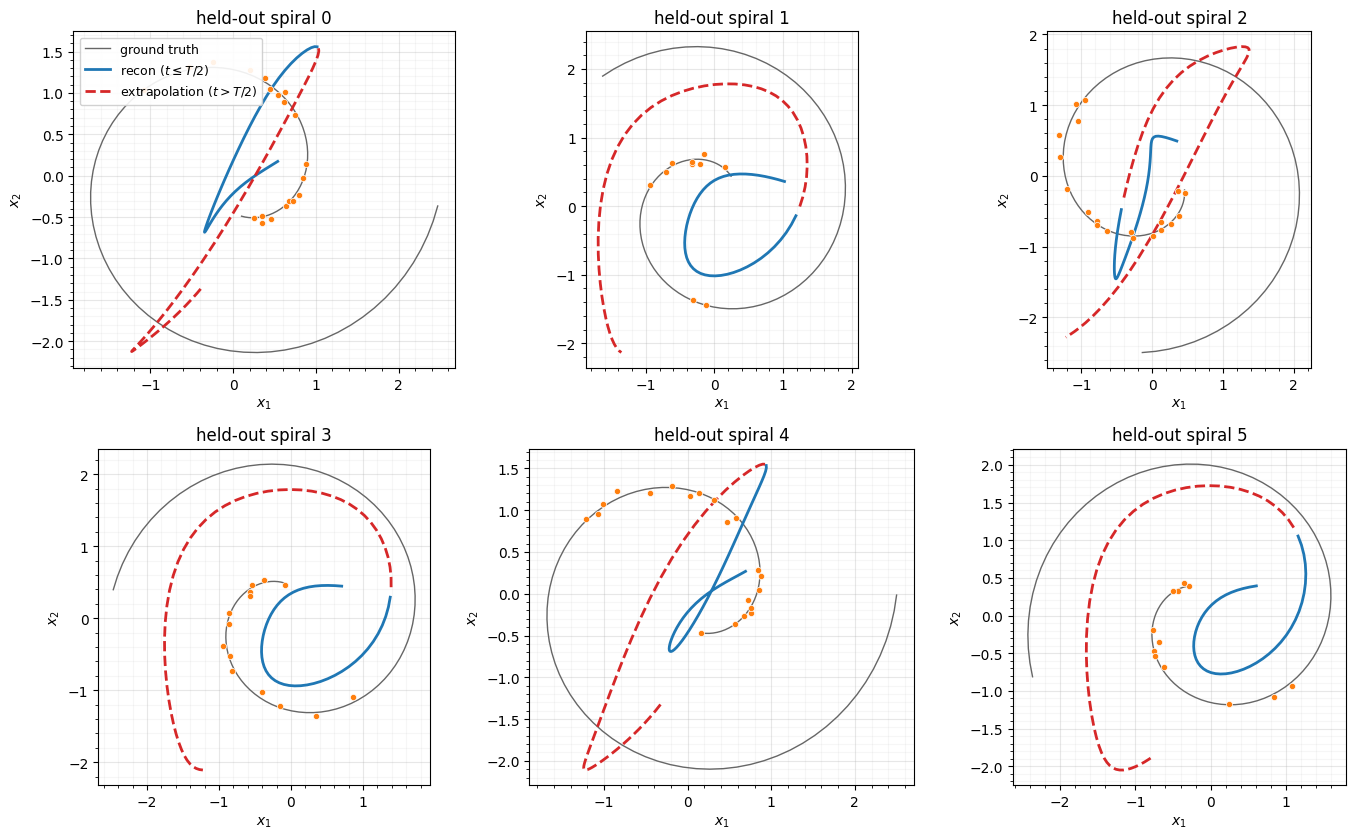

In [6]:
T_HALF = T_MAX / 2.0
fig, axes = plt.subplots(2, 3, figsize=(14, 8.5))
for k, ax in enumerate(axes.flat):
    mask = t_obs_ev[k] <= T_HALF
    n_keep = int(jnp.sum(mask))
    if n_keep < 4:
        ax.set_visible(False); continue
    t_half, x_half = t_obs_ev[k][:n_keep], x_obs_ev[k][:n_keep]
    mu, _ = model.encode(t_half, x_half)
    x_hat = model.decode(mu, t_dense)  # posterior mean for a clean curve
    dense_obs = np.asarray(t_dense <= T_HALF)
    ax.plot(np.asarray(x_clean_ev[k, :, 0]), np.asarray(x_clean_ev[k, :, 1]), color="0.4", lw=1.0, label="ground truth")
    ax.plot(np.asarray(x_hat[dense_obs, 0]), np.asarray(x_hat[dense_obs, 1]), color=DATA_COLOR, lw=2.0, label=r"recon ($t\leq T/2$)")
    ax.plot(np.asarray(x_hat[~dense_obs, 0]), np.asarray(x_hat[~dense_obs, 1]), color="tab:red", lw=2.0, ls="--", label=r"extrapolation ($t>T/2$)")
    ax.scatter(np.asarray(x_half[:, 0]), np.asarray(x_half[:, 1]), s=20, color=LATENT_COLOR, edgecolor="white", linewidth=0.5, zorder=3)
    ax.set(title=f"held-out spiral {k}", xlabel="$x_1$", ylabel="$x_2$")
    ax.set_aspect("equal"); style_ax(ax)
    if k == 0:
        ax.legend(loc="upper left", framealpha=0.9, fontsize=9)
fig.tight_layout()

## 6. The Gaussianization check — the latent code

Now the Gaussianization question for the whole part: how standard-normal is the
latent? The ELBO's KL pulls each $q(z_0\mid x)$ toward the prior, so we plot the
**aggregate posterior** — the encoded $z_0$ across the dataset — against
$\mathcal{N}(0,I)$ and read off its moments.

mean KL(q(z0) || N(0,I)) over dataset: 15.674  (final-epoch batch mean)
aggregate latent moments (target 0, 1, 0, 0):
  z0[0]: mean=+1.324  std=1.491  skew=+0.203  exc-kurt=-0.715
  z0[1]: mean=-1.270  std=0.995  skew=-0.105  exc-kurt=-1.654
  z0[2]: mean=-1.117  std=1.028  skew=+0.057  exc-kurt=-0.786
  z0[3]: mean=+0.510  std=1.150  skew=-0.296  exc-kurt=-0.490


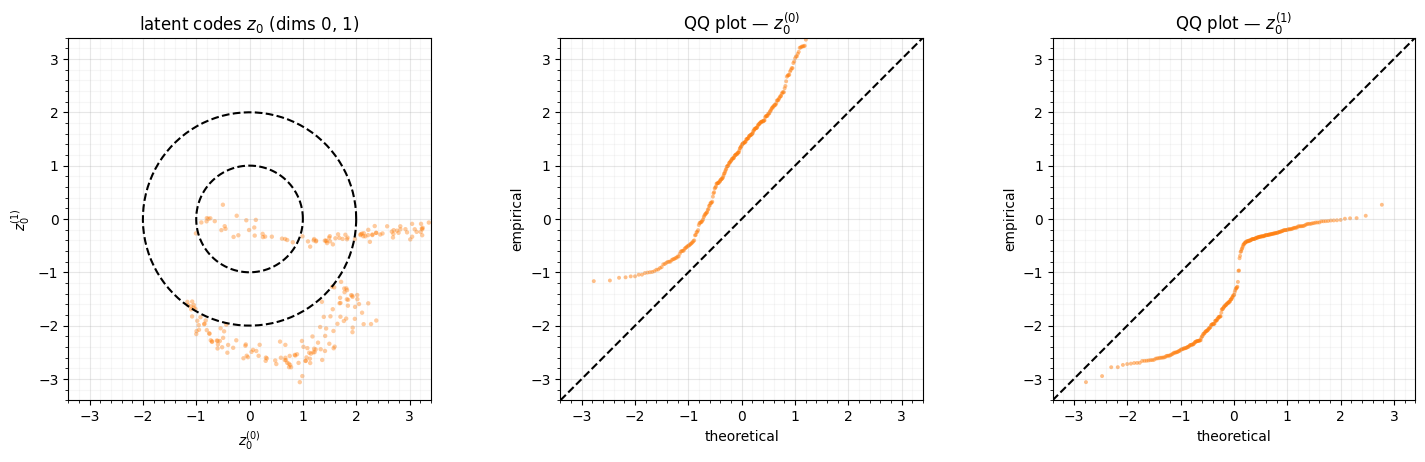

In [7]:
mus = jax.vmap(lambda t, x: model.encode(t, x)[0])(t_obs, x_obs)  # posterior means, (N_TRAJ, LATENT_DIM)
mus = np.asarray(mus)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
ax = axes[0]
ax.scatter(mus[:, 0], mus[:, 1], color=LATENT_COLOR, **SCATTER_KW)
th = np.linspace(0, 2 * np.pi, 200)
for r in (1.0, 2.0):
    ax.plot(r * np.cos(th), r * np.sin(th), **GAUSS_KW)
ax.set(title=r"latent codes $z_0$ (dims 0, 1)", xlabel="$z_0^{(0)}$", ylabel="$z_0^{(1)}$",
       xlim=(-3.4, 3.4), ylim=(-3.4, 3.4))
ax.set_aspect("equal"); style_ax(ax)
for j, ax in enumerate(axes[1:]):
    osm, osr = stats.probplot(mus[:, j], dist="norm", fit=False)
    ax.scatter(osm, osr, color=LATENT_COLOR, s=8, alpha=0.5, edgecolors="none")
    ax.plot([-3.4, 3.4], [-3.4, 3.4], **GAUSS_KW)
    ax.set(title=f"QQ plot — $z_0^{{({j})}}$", xlabel="theoretical", ylabel="empirical",
           xlim=(-3.4, 3.4), ylim=(-3.4, 3.4))
    ax.set_aspect("equal"); style_ax(ax)
fig.tight_layout()

print(f"mean KL(q(z0) || N(0,I)) over dataset: {np.mean(kls[-1]):.3f}  (final-epoch batch mean)")
print("aggregate latent moments (target 0, 1, 0, 0):")
for j in range(LATENT_DIM):
    z = mus[:, j]
    print(f"  z0[{j}]: mean={z.mean():+.3f}  std={z.std():.3f}  skew={stats.skew(z):+.3f}  exc-kurt={stats.kurtosis(z):+.3f}")

The KL did its job in part — the codes are roughly centred and unit-scale, not the
runaway spread an unregularised autoencoder would give — but they are plainly **not**
$\mathcal{N}(0,I)$: the scatter shows arc-like clusters, the QQ plots bend off the
diagonal, and the strongly **negative excess kurtosis** is the fingerprint of a
ring / bimodal distribution rather than a Gaussian. That is not just the usual VAE
aggregate-posterior gap; it is a **topological obstruction**. The spiral family is
indexed by a *circular* phase and a *binary* direction, and neither a circle nor two
discrete modes can be pushed smoothly into a Euclidean $\mathcal{N}(0,I)$ — the same
wall the bijective flows of Parts 0-5 hit on periodic data.

This is the honest limit of *stochastic* Gaussianization, and it points three ways:
to **Part 8** (surjections / stochastic transforms that formalise this lossy
encode-decode), to **Part 10** (non-Euclidean Gaussianization — the right target
geometry for a circular latent), and to **Part 19** (replacing the fixed
$\mathcal{N}(0,I)$ prior with a learned flow prior that *can* absorb such structure).
What the latent ODE delivers regardless is the practical payoff above: a single
code, learned through a standard-normal prior, from which the ODE reconstructs and
extrapolates irregular trajectories.

## Recap — and the end of Part 6

| | bijective CNF (00-02) | latent ODE (here) |
|---|---|---|
| maps | data point $\leftrightarrow \mathcal{N}(0,I)$ | whole trajectory $\to$ code $z_0$ |
| invertible | yes, exactly | no — stochastic encode/decode (ELBO) |
| log-det | trace integral / $t\,\operatorname{tr}(W)$ | n/a — KL to the prior instead |
| dimension | preserved | changed ($\mathbb{R}^{N\times 2}\to\mathbb{R}^{d_z}$) |
| handles | fixed-$d$ vectors | irregular, variable-length sequences |

Part 6 walked the continuous-time family from one end to the other: the free-form
**FFJORD** with its trace-integral log-det (00), the **Hutchinson** estimator that
makes that trace scale (01), the closed-form **matrix-exponential** linear flow (02),
and now the **latent ODE**, which gives up bijectivity to Gaussianize structured,
irregular trajectories into a latent code. The first three are continuous *bijections*;
this last is a continuous *stochastic* transform — the hinge to **Part 8** (SurVAE
surjections & stochastic flows).

**Where this goes next.** The latent ODE is the template for **Part 11** (time-series
Gaussianization — autoregressive and latent-ODE models for sequences) and feeds the
probabilistic-programming integrations of **Part 19** (flows and latent-variable
models as priors/guides). Part 6 is complete.